# MLOps walkthrough

The same lifecycle `python -m src.pipeline` runs, one stage at a time, so the intermediate
state is visible: what validation actually returned, what the splits look like, what goes
into a bundle, and what the gate decided.

This notebook calls the same functions the CLI calls. Nothing here is notebook-only code.

In [1]:
import sys, json
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import yaml

with open("../configs/train_config.yaml", encoding="utf-8") as handle:
    config = yaml.safe_load(handle)

# Paths in the config are relative to the repository root; this notebook runs one level
# down, so point the dataset cache back at the shared location rather than creating a
# second copy under notebooks/.
config["data"]["cache_dir"] = "../data/cache"

print("model:", config["model"]["type"])
print("split: test", config["data"]["test_size"], "| validation", config["data"]["validation_size"])
print("gate :", {k: v for k, v in config["validation"].items() if k != "data"})

model: logistic_regression
split: test 0.2 | validation 0.2
gate : {'min_accuracy': 0.75, 'min_f1': 0.75, 'min_accuracy_over_baseline': 0.2, 'max_latency_ms': 100}


## 1. Acquire and validate

`load_and_preprocess` returns four things: the frame, a content hash, a provenance record,
and the validation report. It writes nothing.

In [2]:
from src.data_pipeline import load_and_preprocess

df, data_hash, provenance, report = load_and_preprocess(config)

print("rows:", len(df), "| data hash:", data_hash)
print()
print(json.dumps(provenance, indent=2))

2026-08-21 19:57:35,759 - src.datasets - INFO - Using cached dataset archive ..\data\cache\uci-sentiment-labelled-sentences.zip


2026-08-21 19:57:35,767 - src.datasets - WARNING - Skipped 2 unparseable lines while reading uci-sentiment-labelled-sentences


2026-08-21 19:57:35,776 - src.datasets - INFO - Parsed 3000 labelled sentences from Sentiment Labelled Sentences


2026-08-21 19:57:35,855 - src.data_pipeline - INFO - Data ready: 3000 rows, 6 columns, hash=1bd179ebe27e, source=uci-sentiment-labelled-sentences


rows: 3000 | data hash: 1bd179ebe27e

{
  "kind": "licensed-download",
  "key": "uci-sentiment-labelled-sentences",
  "name": "Sentiment Labelled Sentences",
  "url": "https://archive.ics.uci.edu/static/public/331/sentiment+labelled+sentences.zip",
  "sha256": "afc26626d710899948693e1a61405dce197f57ffa719fa1130d346b4cc095343",
  "license": "CC BY 4.0",
  "license_url": "https://creativecommons.org/licenses/by/4.0/",
  "citation": "Kotzias, D. (2015). Sentiment Labelled Sentences [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C57604",
  "homepage": "https://archive.ics.uci.edu/dataset/331/sentiment+labelled+sentences"
}


In [3]:
print("validation passed:", report["overall_passed"])
for name in ("null_check", "duplicate_check", "class_balance"):
    check = report[name]
    print(f"  {name:<16} passed={check['passed']}")
print()
print("duplicate rows: {:.2%}".format(report["duplicate_check"]["duplicate_percentage"]))

validation passed: True
  null_check       passed=True
  duplicate_check  passed=True
  class_balance    passed=True

duplicate rows: 0.57%


The duplicate figure is the one to watch. An earlier version of this pipeline ran on
template-generated text that was 99% duplicates, logged a warning, and went on to report
100% accuracy. `validation.data.on_failure: error` now stops that run instead.

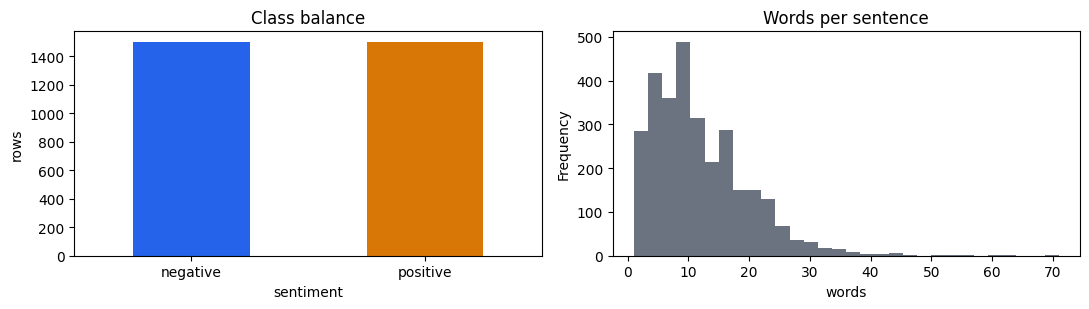

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
df["sentiment"].value_counts().plot(kind="bar", ax=axes[0], color=["#2563eb", "#d97706"], rot=0)
axes[0].set_title("Class balance"); axes[0].set_ylabel("rows")
df["word_count"].plot(kind="hist", bins=30, ax=axes[1], color="#6b7280")
axes[1].set_title("Words per sentence"); axes[1].set_xlabel("words")
plt.tight_layout(); plt.show()

## 2. Split

Three splits from one seed. The test split is set aside now and not touched again until
step 5.

In [5]:
from src.train import three_way_split

labels = df["sentiment"].to_numpy()
train_df, validation_df, test_df, y_train, y_validation, y_test = three_way_split(
    df, labels, config["data"]["test_size"], config["data"]["validation_size"],
    config["data"]["random_state"],
)
print(f"train {len(train_df)} | validation {len(validation_df)} | test {len(test_df)}")

overlap = (set(train_df.index) & set(test_df.index)) | (set(validation_df.index) & set(test_df.index))
print("overlapping rows between splits:", len(overlap))

train 1800 | validation 600 | test 600
overlapping rows between splits: 0


## 3. Fit features on the training split only

`fit_transform_train` is the only method in the feature store that fits anything.
Everything else goes through `transform`, which cannot fit. That is what makes the
no-leakage claim checkable rather than a comment.

In [6]:
from src.feature_store import FeatureStore

store = FeatureStore(config)
X_train = store.fit_transform_train(train_df)
X_validation = store.transform(validation_df)

print("train matrix     :", X_train.shape)
print("validation matrix:", X_validation.shape)
print("tf-idf terms     :", store.metadata["tfidf_features"])
print("numeric columns  :", store.metadata["numeric_columns"])

2026-08-21 19:57:37,051 - src.feature_store - INFO - TF-IDF fitted: 3461 features from 1800 documents


2026-08-21 19:57:37,055 - src.feature_store - INFO - Numeric features scaled: 2 columns


2026-08-21 19:57:37,058 - src.feature_store - INFO - Final feature matrix: (1800, 3463)


train matrix     : (1800, 3463)
validation matrix: (600, 3463)
tf-idf terms     : 3461
numeric columns  : ['review_length', 'word_count']


In [7]:
# A token that exists only outside the training split must never enter the vocabulary.
marker = "zzhapaxmarker"
probe = test_df.copy()
probe.loc[probe.index[0], "review_text_clean"] += " " + marker

print("marker in fitted vocabulary:", marker in set(store.tfidf.get_feature_names_out()))
print("transform still accepts the row:", store.transform(probe).shape)

marker in fitted vocabulary: False
transform still accepts the row: (600, 3463)


## 4. Train

Cross-validation on the training split, then a final fit, then metrics on **validation**.
The test split is not scored here — that is the whole point of having three splits.

In [8]:
from src.train import train_model

model, training_metrics = train_model(X_train, y_train, X_validation, y_validation, config)

for key in ("cv_mean", "cv_std", "validation_accuracy", "validation_f1_weighted", "baseline_accuracy"):
    print(f"{key:<24} {training_metrics[key]:.4f}")

2026-08-21 19:57:37,123 - src.train - INFO - Built logistic_regression with {'C': 1.0, 'max_iter': 1000, 'solver': 'lbfgs'}


2026-08-21 19:57:37,336 - src.train - INFO - CV f1_weighted: 0.7915 +/- 0.0132


2026-08-21 19:57:37,337 - src.train - INFO - Fitting final model on 1800 training rows


2026-08-21 19:57:37,396 - src.train - INFO - Validation accuracy 0.8117 (majority baseline 0.5000) | weighted F1 0.8114


2026-08-21 19:57:37,398 - src.train - INFO - MLflow logging disabled in config; skipping


cv_mean                  0.7915
cv_std                   0.0132
validation_accuracy      0.8117
validation_f1_weighted   0.8114
baseline_accuracy        0.5000


## 5. Bundle, then evaluate on the test split

The candidate is written atomically: model, transformers, metrics, lineage, a pending
evaluation report and a manifest of SHA-256 checksums. Evaluation then loads it back
through the same path serving uses, so a broken bundle fails here rather than in
production.

In [9]:
from pathlib import Path
from src.model_bundle import create_candidate_bundle, load_trusted_bundle

workspace = Path("_walkthrough")
bundle_path = workspace / "candidates" / "sentiment-classifier"

lineage = {
    "data_hash": data_hash,
    "data_rows": len(df),
    "dataset": provenance,
    "data_validation": {"overall_passed": report["overall_passed"],
                        "duplicate_percentage": report["duplicate_check"]["duplicate_percentage"],
                        "min_class_percentage": report["class_balance"]["min_class_percentage"]},
    "evaluation_rows": len(test_df),
    "experiment": "walkthrough",
    "feature_schema": {"label_column": "sentiment",
                       "numeric_columns": store.metadata["numeric_columns"],
                       "text_column": "review_text"},
    "model_type": config["model"]["type"],
    "split": {"random_state": config["data"]["random_state"], "stratified": True,
              "test_size": config["data"]["test_size"],
              "validation_size": config["data"]["validation_size"]},
    "training_rows": len(train_df),
    "validation_rows": len(validation_df),
}
create_candidate_bundle(str(bundle_path), model, store.export_transformers(),
                        training_metrics, lineage, int(X_train.shape[1]))

manifest = json.loads((bundle_path / "manifest.json").read_text())
print("format:", manifest["bundle_format_version"], "| expected dim:", manifest["expected_feature_dimension"])
for name, digest in manifest["artifact_checksums"].items():
    print(f"  {name:<30} {digest[:16]}...")

format: 1.1 | expected dim: 3463
  evaluation_report.json         b0d22d9b51774f60...
  feature_transformers.joblib    231fa2f3cbb8d035...
  lineage.json                   3990d6931a6b7fe7...
  model.joblib                   15d83cf25d47da69...
  training_metrics.json          2c0bdf67f5c69492...


In [10]:
from src.evaluate import ModelEvaluator, PerformanceGate, build_evaluation_report
from src.model_bundle import update_evaluation_report

loaded_model, transformers, manifest = load_trusted_bundle(str(bundle_path))
eval_store = FeatureStore(config)
eval_store.import_transformers(transformers)
X_test = eval_store.transform(test_df)

evaluator = ModelEvaluator(loaded_model, config)
metrics = evaluator.compute_metrics(X_test, y_test)
latency = evaluator.measure_latency(X_test)
gate = PerformanceGate(config).evaluate(metrics, latency)
update_evaluation_report(str(bundle_path), build_evaluation_report(metrics, latency, gate, data_hash))

print(f"test accuracy       {metrics['accuracy']:.4f}")
print(f"majority baseline   {metrics['baseline_accuracy']:.4f}")
print(f"margin              {metrics['accuracy_over_baseline']:.4f}")
print(f"weighted F1         {metrics['f1_weighted']:.4f}")
print(f"ROC-AUC             {metrics['roc_auc']:.4f}")
print(f"p95 latency         {latency['p95_latency_ms']:.3f} ms")

test accuracy       0.8067
majority baseline   0.5000
margin              0.3067
weighted F1         0.8067
ROC-AUC             0.8795
p95 latency         0.067 ms


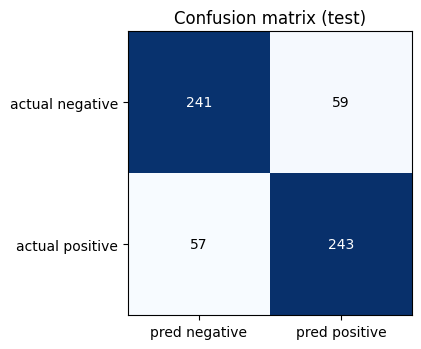

In [11]:
import numpy as np

matrix = np.array(metrics["confusion_matrix"])
labels = metrics["confusion_matrix_labels"]

fig, ax = plt.subplots(figsize=(4.2, 3.6))
ax.imshow(matrix, cmap="Blues")
ax.set_xticks(range(len(labels)), [f"pred {l}" for l in labels])
ax.set_yticks(range(len(labels)), [f"actual {l}" for l in labels])
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        ax.text(j, i, matrix[i, j], ha="center", va="center",
                color="white" if matrix[i, j] > matrix.max() / 2 else "black")
ax.set_title("Confusion matrix (test)")
plt.tight_layout(); plt.show()

## 6. The gate

Four checks. The one that carries the most meaning is the margin over the majority-class
baseline: a bare accuracy floor would pass a model that always predicts the larger class
on an imbalanced dataset.

In [12]:
for name, check in gate["checks"].items():
    verdict = "pass" if check["passed"] else "FAIL"
    print(f"  {name:<24} {check['value']:>8.4f}  vs {check['threshold']:<8}  {verdict}")
print()
print("overall:", "PASSED" if gate["overall_passed"] else "FAILED")

  accuracy                   0.8067  vs 0.75      pass
  f1_weighted                0.8067  vs 0.75      pass
  accuracy_over_baseline     0.3067  vs 0.2       pass
  latency_p95                0.0670  vs 100       pass

overall: PASSED


## 7. Register and promote

Registration copies and revalidates the whole bundle. Production requires a passing
staging version — direct registration into production is rejected.

In [13]:
from src.model_registry import LocalModelRegistry

registry = LocalModelRegistry(registry_dir=str(workspace / "registry"))
version = registry.register_model("sentiment-classifier", str(bundle_path), stage="staging")
registry.transition_stage("sentiment-classifier", version, "production")

entry = registry.get_production_model("sentiment-classifier")
print("version:", entry["version"], "| stage:", entry["stage"], "| bundle:", entry["bundle_path"])

2026-08-21 19:57:38,008 - src.model_registry - INFO - Registered sentiment-classifier v1 (stage=staging)


2026-08-21 19:57:38,055 - src.model_registry - INFO - Transitioned sentiment-classifier v1: staging → production


version: v1 | stage: production | bundle: sentiment-classifier/v1


## 8. Serve

From a shell, against the bundle the reference run produced:

```bash
python -m src.serve --bundle_path models/registry/sentiment-classifier/v1 --host 127.0.0.1 --port 8000

curl -s localhost:8000/ready
curl -s -X POST localhost:8000/predict -H 'Content-Type: application/json' \
  -d '{"text": "this product is excellent and works great"}'
```

The service loads exactly one bundle that the registry marks as production, verifies its
checksums and feature dimension first, and returns 503 on `/ready` until that succeeds.

---

Further reading: [architecture and design decisions](../docs/ARCHITECTURE.md),
[data provenance](../docs/DATA.md), [how the gate thresholds were chosen](../docs/EVALUATION.md),
[what production would add](../docs/PRODUCTION.md).

In [14]:
import shutil
shutil.rmtree(workspace, ignore_errors=True)
print("walkthrough artifacts removed")

walkthrough artifacts removed
